# UChicago ADS — RAG Q&A Pipeline

```
┌─────────────────────────────────────────────────────────────────┐
│                        DATA PREPARATION                        │
│                                                                 │
│  Web Crawl (depth=3)  →  Page Labeling  →  HTML Parsing        │
│  147 pages collected      topic labels      main-content scope  │
└──────────────────────────────┬──────────────────────────────────┘
                               ▼
┌─────────────────────────────────────────────────────────────────┐
│                          CHUNKING                               │
│                                                                 │
│  Accordion pages → parent chunk + sub-chunks (schedule/course/  │
│                    FAQ/jobs/generic)                             │
│  FAQ pages       → Q&A pairs (<details>, <dt/dd>, heading-Q)   │
│  Regular pages   → page parent chunk + section sub-chunks       │
│                    (800 char, 150 overlap)                       │
│  Career outcomes → manual company name injection (image logos)  │
└──────────────────────────────┬──────────────────────────────────┘
                               ▼
┌─────────────────────────────────────────────────────────────────┐
│                    INDEXING & EMBEDDING                         │
│                                                                 │
│  all-MiniLM-L6-v2 (384-dim)  →  FAISS IndexFlatIP (cosine)    │
│  BM25Okapi (tokenized text)                                    │
└──────────────────────────────┬──────────────────────────────────┘
                               ▼
┌─────────────────────────────────────────────────────────────────┐
│                         RETRIEVAL                               │
│                                                                 │
│  Query → Synonym Expansion (bidirectional)                      │
│        → BM25 scores + FAISS semantic scores + Heading boost    │
│        → RRF fusion (k=60)                                      │
│        → Per-URL cap + dedup                                    │
│        → Cross-encoder reranking (ms-marco-MiniLM-L-6-v2)      │
└──────────────────────────────┬──────────────────────────────────┘
                               ▼
┌─────────────────────────────────────────────────────────────────┐
│                       LLM GENERATION                           │
│                                                                 │
│  gemini-2.5-flash-lite  ←  retrieved context + prompt          │
│  Markdown output with source references                         │
└─────────────────────────────────────────────────────────────────┘
```

## Initialize

Setup environment and imports.

In [1]:
# ── stdlib ──────────────────────────────────────────────────────
import json
import os
import pprint
import random
import re
from collections import Counter, defaultdict, deque
from time import sleep
from urllib.parse import urljoin, urlparse

# ── third-party ─────────────────────────────────────────────────
import faiss
import matplotlib.pyplot as plt
import numpy as np
import requests
from bs4 import BeautifulSoup
from dotenv import load_dotenv
from nltk import download
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
from rank_bm25 import BM25Okapi
from sentence_transformers import CrossEncoder, SentenceTransformer

# ── langchain / RAG ────────────────────────────────────────────
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_google_genai import ChatGoogleGenerativeAI

# ── evaluation ──────────────────────────────────────────────────
from datasets import Dataset
from ragas import evaluate
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore", DeprecationWarning)
    from ragas.metrics import answer_relevancy, faithfulness
    from ragas.llms import LangchainLLMWrapper
    from ragas.embeddings import LangchainEmbeddingsWrapper
    from langchain_community.embeddings import HuggingFaceEmbeddings

## 1. Data Preparation

### 1.1 Web Crawling

Crawl the UChicago ADS website (depth=3) to collect all program-related pages.
Pages are stored with raw HTML for downstream parsing.

In [2]:
base_domain = "datascience.uchicago.edu"
main_domain = "datascience.uchicago.edu/education/masters-programs/"
start_url = "https://datascience.uchicago.edu/education/masters-programs/ms-in-applied-data-science/"
max_depth = 3

visited = set()
collected_pages = {}
link_structure = defaultdict(list)
depth_map = {}
to_visit = deque()
to_visit.append((start_url, 0))

def is_internal(url):
    parsed = urlparse(url)
    is_same_domain = parsed.netloc == "" or base_domain in parsed.netloc
    return is_same_domain

def should_crawl_children(url):
    return main_domain in url

def crawl_page(url, depth):
    try:
        res = requests.get(url, timeout=10)
        if res.status_code != 200:
            return
        soup = BeautifulSoup(res.text, "html.parser")
        text = soup.get_text(separator="\n", strip=True)
        title_tag = soup.find("title")
        title = title_tag.get_text(separator="\n",strip=True)

        collected_pages[url] = {
            "title": title,
            "text": text,
            "_raw_html": res.text,  # preserved for JS-render detection
        }

        depth_map[url] = depth

        if not should_crawl_children(url):
            return

        for a in soup.find_all("a", href=True):
            link = urljoin(url, a["href"]).split("#")[0]
            print(f"Found link: {link}, is_internal: {is_internal(link)}")
            if is_internal(link) and link not in visited:
                if link not in (u for u, _ in to_visit) and depth + 1 <= max_depth:
                    to_visit.append((link, depth + 1))
                    link_structure[url].append(link)

        sleep(0.1) 
    except Exception as e:
        print(f"Failed to crawl {url}: {e}")

while to_visit:
    url, depth = to_visit.popleft()
    if url in visited:
        continue
    visited.add(url)
    crawl_page(url, depth)


Found link: https://datascience.uchicago.edu/education/masters-programs/ms-in-applied-data-science/, is_internal: True
Found link: https://datascience.uchicago.edu, is_internal: True
Found link: https://datascience.uchicago.edu, is_internal: True
Found link: https://datascience.uchicago.edu/about/, is_internal: True
Found link: https://datascience.uchicago.edu/about/about-dsi/, is_internal: True
Found link: https://datascience.uchicago.edu/about/about-dsi/, is_internal: True
Found link: https://datascience.uchicago.edu/about/jobs/, is_internal: True
Found link: https://datascience.uchicago.edu/about/visiting-dsi/, is_internal: True
Found link: https://datascience.uchicago.edu/about/contact/, is_internal: True
Found link: https://datascience.uchicago.edu/education/, is_internal: True
Found link: https://datascience.uchicago.edu/education/undergrad-major/, is_internal: True
Found link: https://datascience.uchicago.edu/education/undergrad-major/, is_internal: True
Found link: https://data

In [3]:
# [Optional-EDA] Page word count statistics
print(f"\nCrawled {len(collected_pages)} pages (up to depth {max_depth})")
for parent, children in list(link_structure.items())[:10]:
    print(f"\n{parent} (depth={depth_map[parent]})")
    for child in children[:5]:
        print("  └─", child)


Crawled 147 pages (up to depth 3)

https://datascience.uchicago.edu/education/masters-programs/ms-in-applied-data-science/ (depth=0)
  └─ https://datascience.uchicago.edu
  └─ https://datascience.uchicago.edu/about/
  └─ https://datascience.uchicago.edu/about/about-dsi/
  └─ https://datascience.uchicago.edu/about/jobs/
  └─ https://datascience.uchicago.edu/about/visiting-dsi/

https://datascience.uchicago.edu/education/masters-programs/ (depth=1)
  └─ https://datascience.uchicago.edu/data-science-clinic/
  └─ https://datascience.uchicago.edu/people/greg-green/
  └─ https://datascience.uchicago.edu/people/kristin-i-mccann/
  └─ https://datascience.uchicago.edu/news/pit-un-grant-supports-dsi-community-data-fellows-program/
  └─ https://datascience.uchicago.edu/news/mscapp-conference-invites-conversation-about-ai-research-ethics-and-equality/

https://datascience.uchicago.edu/education/masters-programs/ms-in-applied-data-science/in-person-program/ (depth=1)
  └─ https://datascience.uchic

In [4]:
# [Optional-EDA] Word count distribution histogram
page_word_counts = {}
total_word_count = 0

for url, page_info in collected_pages.items():
    text = page_info.get("text", "") # Get the text content, default to empty string if not found
    words = text.split() # Split the text into words
    word_count = len(words) # Count the number of words
    page_word_counts[url] = word_count
    total_word_count += word_count

print("\n--- Page Word Count Statistics ---")
print(f"Total number of crawled pages: {len(collected_pages)}")
print(f"Total word count across all crawled pages: {total_word_count}")

# print word counts for each page
print("\nWord count per page:")
for url, count in page_word_counts.items():
    print(f"{url}: {count} words")

# find the page with the most/least words
if page_word_counts:
    max_word_page = max(page_word_counts, key=page_word_counts.get)
    min_word_page = min(page_word_counts, key=page_word_counts.get)
    mean_word_count= total_word_count / len(collected_pages) if len(collected_pages) > 0 else 0
    print(f"\nPage with the most words: {max_word_page} ({page_word_counts[max_word_page]} words)")
    print(f"Page with the least words: {min_word_page} ({page_word_counts[min_word_page]} words)")
    print(f"Average word count per page: {mean_word_count:.2f} words")
else:
    print("\nNo pages were crawled to calculate word counts.")


--- Page Word Count Statistics ---
Total number of crawled pages: 147
Total word count across all crawled pages: 219400

Word count per page:
https://datascience.uchicago.edu/education/masters-programs/ms-in-applied-data-science/: 1251 words
https://datascience.uchicago.edu: 1397 words
https://datascience.uchicago.edu/about/: 891 words
https://datascience.uchicago.edu/about/about-dsi/: 1099 words
https://datascience.uchicago.edu/about/jobs/: 2733 words
https://datascience.uchicago.edu/about/visiting-dsi/: 951 words
https://datascience.uchicago.edu/about/contact/: 1181 words
https://datascience.uchicago.edu/education/: 1058 words
https://datascience.uchicago.edu/education/undergrad-major/: 1282 words
https://datascience.uchicago.edu/education/masters-programs/: 1432 words
https://datascience.uchicago.edu/education/phd-in-data-science/: 939 words
https://datascience.uchicago.edu/education/data-science-clinic/: 1590 words
https://datascience.uchicago.edu/education/summer-research-program

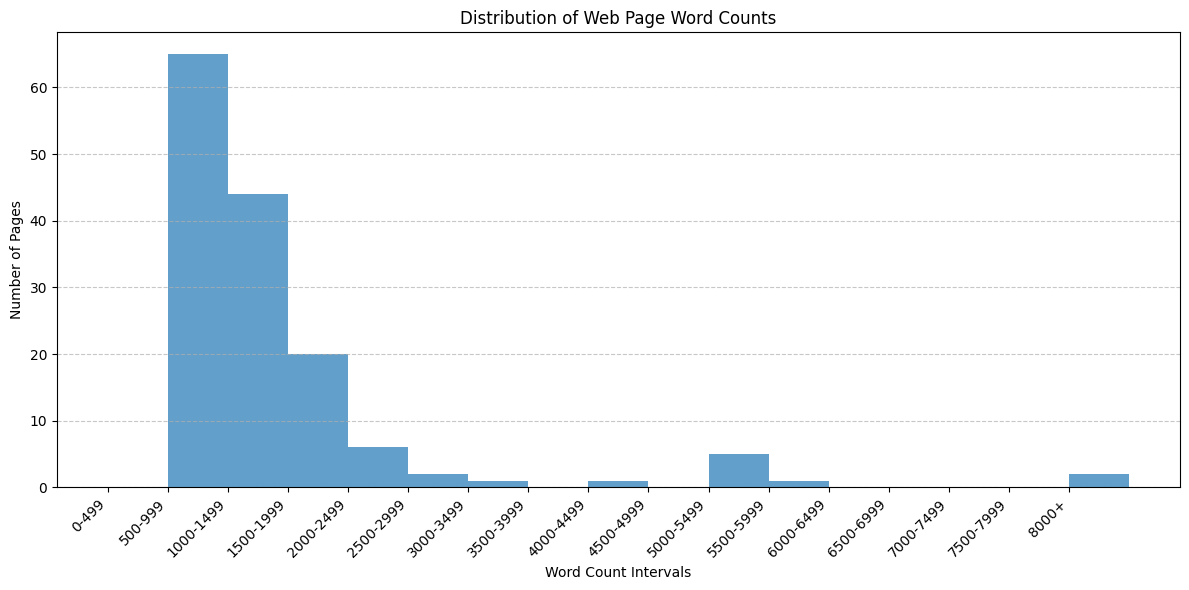

In [5]:
# [Optional-EDA] Word count distribution histogram
max_word_count = max(page_word_counts.values()) if page_word_counts else 0
bins = np.arange(0, max_word_count + 500, 500)
if max_word_count == 0:
    bins = [0, 500]

hist, bin_edges = np.histogram(list(page_word_counts.values()), bins=bins)

plt.figure(figsize=(12, 6))
plt.bar(bin_edges[:-1], hist, width=np.diff(bin_edges), align='edge', alpha=0.7)

plt.title("Distribution of Web Page Word Counts")
plt.xlabel("Word Count Intervals")
plt.ylabel("Number of Pages")

bin_labels = [f"{int(bin_edges[i])}-{int(bin_edges[i+1]-1)}" for i in range(len(bin_edges)-1)]
if len(bin_labels) > 0:
    bin_labels[-1] = f"{int(bin_edges[-2])}+"

plt.xticks(bin_edges[:-1], bin_labels, rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

In [6]:
output_file = "uchicago_ads_pages_depth3.json"

pages_to_save = [
    {
        "url":       url,
        "depth":     depth_map.get(url, -1),
        "title":     info.get("title", ""),
        "text":      info.get("text", ""),
        "_raw_html": info.get("_raw_html", ""),
    }
    for url, info in collected_pages.items()
]

with open(output_file, "w", encoding="utf-8") as f:
    json.dump(pages_to_save, f, indent=2, ensure_ascii=False)

print(f"\n✅ Saved {len(pages_to_save)} pages to {output_file}")


✅ Saved 147 pages to uchicago_ads_pages_depth3.json


### 1.2 Page Labeling

Assign topic labels (admission, career, curriculum, etc.) to each page
using keyword matching. Labels are used for retrieval-time filtering.

In [7]:
keyword_groups = {
    "admission": ["admission", "apply", "application", "enrollment"],
    "career": ["career", "job", "employment", "profession"],
    "capstone": ["capstone", "final project", "research"],
    "fee": ["tuition", "cost", "fee", "price"],
    "course": ["course", "class", "curriculum", "track"],
    "foundational": ["prequarter", "pre-quarter", "Quarter 1"],
    "resource": ["resource", "career", "support", "help"],
    "schedule": ["schedule", "timetable", "class time", "quarter"],
    "application": ["application", "deadline", " due ", "submission"],
    "scholarship": ["scholarship", "financial aid"],
    "english": ["toefl", "ielts", " gre ", "language requirement", "english score"],
    "visa": ["visa", "sponsorship", "international student"],
    "faculty": ["faculty", "instructor", "professor", "teacher","staff","scholar","fellow","people"],
    "contact" : ["contact","outreach","network","workshop"],
    "news" : ["news","event"],
}

In [8]:
download('wordnet')
download('omw-1.4')

lemmatizer = WordNetLemmatizer()

def normalize(text: str) -> str:
    text = re.sub(r'[^a-z0-9\s]', '', text.lower())
    tokens = text.split()
    lemmas = [lemmatizer.lemmatize(tok, pos='n') for tok in tokens]
    return ' '.join(lemmas)

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/pengxiao/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/pengxiao/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [9]:
def extract_labels(title, url, keyword_groups) -> list:
    norm = normalize(title) + " " + normalize(url)
    labels = []
    for grp, synonyms in keyword_groups.items():
        for word in synonyms:
            if word.lower() in norm:
                labels.append(grp)
                break
    return labels if labels else ["other"]

In [10]:
def count_keyword_groups(text, title, url, groups):
    norm = normalize(text) + " " + normalize(title) + " " + normalize(url) + " " + normalize(url) + " " + normalize(url)
    tokens = norm.split()
    counter = Counter(tokens)

    group_hits = {}
    for grp, syns in groups.items():
        hits = 0
        for s in syns:
            hits += counter[s.lower()]
        group_hits[grp] = hits
    return group_hits

In [11]:
def classify_based_on_hits(group_hits, threshold_ratio=0.65, min_total_hits=10):
    total_hits = sum(group_hits.values())
    if total_hits < min_total_hits:
        return "Specific"

    top_hits = sorted(group_hits.values(), reverse=True)[:3]
    top_sum = sum(top_hits)
    ratio = top_sum / total_hits

    if ratio >= threshold_ratio:
        return "Specific"
    else:
        return "General"

In [12]:
annotated_pages = []

for url, info in collected_pages.items():
    title = info["title"]
    text = info["text"]

    # get keyword group count
    group_hits = count_keyword_groups(text, title, url, keyword_groups)

    # get level(General / Specific)
    level = classify_based_on_hits(group_hits, threshold_ratio=0.6, min_total_hits=5)

    # get label
    labels = extract_labels(title, url, keyword_groups)
    if 'people' in url:
      level = 'Specific'

    annotated_pages.append({
        "url": url,
        "title": title,
        "text": text,
        "_raw_html": info.get("_raw_html", ""),
        "labels": labels,
        "level": level,
        "group_hits": group_hits
    })

for page in annotated_pages:
  print("-" * 60)
  print(page['url'])
  print(page['title'])
  print(page['level'],page['labels'])


------------------------------------------------------------
https://datascience.uchicago.edu/education/masters-programs/ms-in-applied-data-science/
Master's in Applied Data Science | DSI
General ['other']
------------------------------------------------------------
https://datascience.uchicago.edu
Homepage | DSI
Specific ['other']
------------------------------------------------------------
https://datascience.uchicago.edu/about/
About | DSI
Specific ['other']
------------------------------------------------------------
https://datascience.uchicago.edu/about/about-dsi/
The UChicago Data Science Institute | DSI
Specific ['other']
------------------------------------------------------------
https://datascience.uchicago.edu/about/jobs/
Jobs & Opportunities | DSI
Specific ['career']
------------------------------------------------------------
https://datascience.uchicago.edu/about/visiting-dsi/
Visiting DSI | DSI
Specific ['other']
---------------------------------------------------------


📊 General/Specific Statistics:
  General: 21 (14.29%)
  Specific: 126 (85.71%)


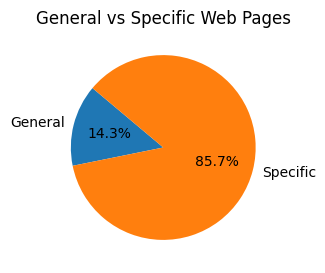

In [13]:
# [Optional-EDA] Labels-per-page distribution
level_counts = Counter(page["level"] for page in annotated_pages)

print("\n📊 General/Specific Statistics:")
for level, count in level_counts.items():
    print(f"  {level}: {count} ({count / len(annotated_pages) * 100:.2f}%)")

plt.figure(figsize=(3, 3))
plt.pie(level_counts.values(), labels=level_counts.keys(), autopct='%1.1f%%', startangle=140)
plt.title("General vs Specific Web Pages")
plt.show()




📚 Label shows in how many pages:
  faculty: 60
  capstone: 31
  other: 23
  news: 22
  contact: 8
  resource: 5
  admission: 4
  career: 3
  course: 2
  application: 2
  fee: 2


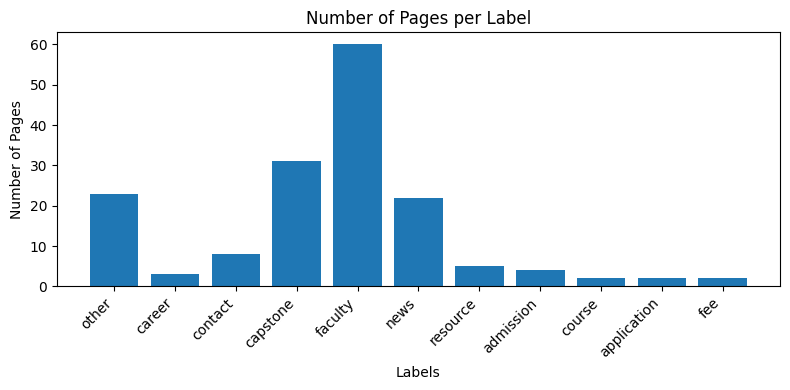

In [14]:
# [Optional-EDA] Label frequency distribution
# how many pages each label appears
label_counter = Counter()
for page in annotated_pages:
    label_counter.update(page["labels"])

print("\n📚 Label shows in how many pages:")
for label, count in label_counter.most_common():
    print(f"  {label}: {count}")

plt.figure(figsize=(8, 4))
plt.bar(label_counter.keys(), label_counter.values())
plt.xticks(rotation=45, ha='right')
plt.xlabel('Labels')
plt.ylabel('Number of Pages')
plt.title('Number of Pages per Label')
plt.tight_layout()
plt.show()


🔢 Page owns how many labels:
  1 label(s): 135 pages
  2 label(s): 9 pages
  3 label(s): 3 pages


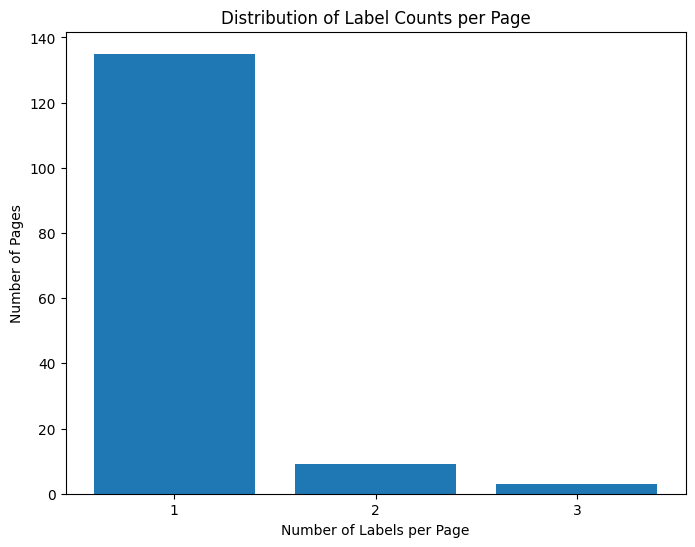

In [15]:
# [Optional-EDA] Labels-per-page distribution
# How many labels each page has
label_num_counter = Counter(len(page["labels"]) for page in annotated_pages)

print("\n🔢 Page owns how many labels:")
for num_labels, count in sorted(label_num_counter.items()):
    print(f"  {num_labels} label(s): {count} pages")

if annotated_pages:
    plt.figure(figsize=(8, 6))
    plt.bar(label_num_counter.keys(), label_num_counter.values())
    plt.xlabel('Number of Labels per Page')
    plt.ylabel('Number of Pages')
    plt.title('Distribution of Label Counts per Page')
    plt.xticks(list(label_num_counter.keys()))
    plt.show()
else:
    print("No pages were annotated, skipping label distribution plot.")

## 2. RAG Pipeline

### 2.1 Chunking

Multi-strategy chunking based on HTML structure:
- **Accordion pages**: Extract each accordion item as a parent chunk; sub-split large items by structure (schedule, nested accordion, jobs, or generic text splitter)
- **FAQ pages**: Extract Q&A pairs from `<details>`, `<dt>/<dd>`, or heading-based patterns
- **Regular pages**: Create a page-level parent chunk + section sub-chunks (800 char, 150 overlap)

Non-accordion content on accordion pages (intro text, program track descriptions) is also extracted.

`.main-content` CSS selector scopes extraction to avoid navigation/footer noise (works on 138/147 pages).

**Design decisions:**
- Parent chunks provide holistic context; sub-chunks enable fine-grained retrieval. Cross-encoder reranking selects the right granularity at query time.
- Career-outcomes company names are manually injected because the source website stores them as image logos with empty alt text.

In [16]:
_ALWAYS_REMOVE_TAGS = ["script", "style", "noscript", "iframe"]
_SKIP_CLASSES = re.compile(
    r"(site-header|site-footer|site-navigation|main-navigation|"
    r"breadcrumb|cookie|social-share|search-form|related-posts|"
    r"mega-menu|mobile-menu|skip-link)",
    re.IGNORECASE,
)

def _clean_soup(soup):
    for tag in _ALWAYS_REMOVE_TAGS:
        for el in soup.find_all(tag):
            el.decompose()
    _ROOT_TAGS = {"html", "head", "body"}
    for el in list(soup.find_all(True)):
        if el.name in _ROOT_TAGS:
            continue
        if not el.attrs:
            continue
        cls = " ".join(el.get("class", []))
        if _SKIP_CLASSES.search(cls):
            el.decompose()
    return soup

def _main_content(soup):
    """Return .main-content element if available, else the full soup."""
    return soup.select_one(".main-content") or soup

def _make_chunk(text, url, chunk_type, **meta):
    text = re.sub(r"\n{3,}", "\n\n", text).strip()
    if not text:
        return None
    return {
        "text": text,
        "metadata": {
            "source_url":  url,
            "chunk_type":  chunk_type,
            "heading":     meta.get("heading"),
            "sub_heading": meta.get("sub_heading"),
        },
    }

_ACCORDION_SUBSPLIT_CHARS = 1500
_FAQ_URL_RE  = re.compile(r"faq|faqs|frequently|q-and-a", re.IGNORECASE)
_FAQ_BODY_RE = re.compile(r"frequently asked|<details|<dt>", re.IGNORECASE)
_QUESTION_RE = re.compile(r".{10,}\?$")

def _subsplit_schedule(content_el, url, heading):
    chunks = []
    for quarter_div in content_el.select("div.quarter"):
        title_el = quarter_div.find(["h3", "h4", "strong"])
        sub_heading = title_el.get_text(strip=True) if title_el else quarter_div.get_text(" ", strip=True)[:60]
        body = quarter_div.get_text(separator="\n", strip=True)
        c = _make_chunk(f"{heading} — {sub_heading}\n{body}", url, "accordion_schedule",
                        heading=heading, sub_heading=sub_heading)
        if c: chunks.append(c)
    return chunks

def _subsplit_nested_accordion(content_el, url, heading):
    """Course pages → accordion_course; FAQ pages (URL contains faq) → accordion_faq.
    Both share the same HTML structure; distinguished by URL.
    """
    chunks = []
    for li in content_el.select("ul.accordion li.accordion__item"):
        title_el = li.select_one(".accordion-title")
        body_el  = li.select_one(".accordion__content")
        if not title_el: continue
        sub_heading = title_el.get_text(strip=True)
        body = body_el.get_text(separator="\n", strip=True) if body_el else li.get_text(separator="\n", strip=True)
        chunk_type = "accordion_faq" if _FAQ_URL_RE.search(url) else "accordion_course"
        c = _make_chunk(f"{heading} — {sub_heading}\n{body}", url, chunk_type,
                        heading=heading, sub_heading=sub_heading)
        if c: chunks.append(c)
    return chunks

def _subsplit_jobs(content_el, url, heading):
    chunks = []
    textblock = content_el.select_one("div.textblock")
    if not textblock: return chunks
    current_h3, current_parts = None, []

    def _flush(h3_text, parts):
        body = "\n".join(parts).strip()
        if not body: return None
        return _make_chunk(f"{heading} — {h3_text}\n{body}", url, "accordion_job",
                           heading=heading, sub_heading=h3_text)

    for el in textblock.children:
        if not hasattr(el, "name") or el.name is None:
            t = str(el).strip()
            if t: current_parts.append(t)
            continue
        if el.name == "h3":
            if current_h3:
                c = _flush(current_h3, current_parts)
                if c: chunks.append(c)
            current_h3, current_parts = el.get_text(strip=True), []
        else:
            current_parts.append(el.get_text(separator="\n", strip=True))
    if current_h3:
        c = _flush(current_h3, current_parts)
        if c: chunks.append(c)
    return chunks

_ACCORDION_TEXT_SPLITTER = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=150)

def _subsplit_generic(content_el, url, heading):
    body = content_el.get_text(separator="\n", strip=True)
    chunks = []
    for i, t in enumerate(_ACCORDION_TEXT_SPLITTER.split_text(body)):
        sub_heading = f"{heading} (part {i+1})"
        c = _make_chunk(f"{heading}\n{t}", url, "accordion_sub",
                        heading=heading, sub_heading=sub_heading)
        if c: chunks.append(c)
    return chunks

def _choose_subsplitter(content_el):
    if content_el.select("div.quarter"):                      return _subsplit_schedule
    if content_el.select("ul.accordion li.accordion__item"): return _subsplit_nested_accordion
    if content_el.select("div.textblock h3"):                return _subsplit_jobs
    return None

def _has_accordion(soup):
    return bool(soup.select(".accordion-item, [data-accordion] > li"))

def _extract_accordion(html, url):
    soup = _clean_soup(BeautifulSoup(html, "html.parser"))
    main = _main_content(soup)
    chunks = []
    for item in main.select(".accordion-item"):
        title_el   = item.select_one(".accordion-title")
        content_el = item.select_one(".accordion-content")
        if not title_el or not content_el: continue
        heading = title_el.get_text(strip=True)
        body    = content_el.get_text(separator="\n", strip=True)
        parent = _make_chunk(f"{heading}\n{body}", url, "accordion",
                             heading=heading, sub_heading=None)
        if parent: chunks.append(parent)
        if len(body) <= _ACCORDION_SUBSPLIT_CHARS:
            continue
        subsplitter = _choose_subsplitter(content_el) or _subsplit_generic
        chunks.extend(subsplitter(content_el, url, heading))

    # Extract non-accordion content (page intro, program track descriptions, etc.)
    for item in main.select(".accordion-item"):
        item.decompose()
    remaining = main.get_text(separator="\n", strip=True)
    if remaining and len(remaining) > 50:
        for t in _TEXT_SPLITTER.split_text(remaining):
            c = _make_chunk(t, url, "section")
            if c:
                chunks.append(c)

    return chunks

_TEXT_SPLITTER = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=150)

def _extract_paragraphs(html, url):
    soup = _clean_soup(BeautifulSoup(html, "html.parser"))
    main = _main_content(soup)
    plain = main.get_text(separator="\n", strip=True)
    chunks = []
    # Page-level parent chunk (full page text for holistic answers)
    parent = _make_chunk(plain, url, "page", heading=None)
    if parent:
        chunks.append(parent)
    # Section sub-chunks (fine-grained retrieval)
    texts = _TEXT_SPLITTER.split_text(plain)
    chunks.extend(c for c in (_make_chunk(t, url, "section") for t in texts) if c)
    return chunks

def _extract_faq(html, url):
    soup = _clean_soup(BeautifulSoup(html, "html.parser"))
    main = _main_content(soup)
    chunks = []
    for details in main.find_all("details"):
        summary = details.find("summary")
        if not summary: continue
        question = summary.get_text(strip=True)
        summary.decompose()
        answer = details.get_text(separator=" ", strip=True)
        c = _make_chunk(f"Q: {question}\nA: {answer}", url, "faq", heading=question)
        if c: chunks.append(c)
    if not chunks:
        for dt in main.find_all("dt"):
            dd = dt.find_next_sibling("dd")
            if dd:
                q = dt.get_text(strip=True)
                a = dd.get_text(separator=" ", strip=True)
                c = _make_chunk(f"Q: {q}\nA: {a}", url, "faq", heading=q)
                if c: chunks.append(c)
    if not chunks:
        for h in main.find_all(["h2", "h3", "h4", "strong"]):
            q = h.get_text(strip=True)
            if not _QUESTION_RE.match(q): continue
            parts = []
            for sib in h.find_next_siblings():
                if sib.name in ("h2", "h3", "h4"): break
                parts.append(sib.get_text(separator=" ", strip=True))
            a = " ".join(parts).strip()
            if a:
                c = _make_chunk(f"Q: {q}\nA: {a}", url, "faq", heading=q)
                if c: chunks.append(c)
    return chunks

_CAREER_INTERNSHIPS = (
    "Career Outcomes - Student Internships: "
    "The following companies have hired UChicago MS in Applied Data Science students as interns: "
    "Amazon, SiriusXM, Teragonia, T-Mobile, BMO, Motorola, Lenovo, CVS Health, Uber, "
    "Deloitte, TransUnion, JLL, Capital One, NASA, Apple, United Nations, UPS"
)
_CAREER_ALUMNI = (
    "Career Outcomes - Alumni Careers: "
    "UChicago MS in Applied Data Science graduates work at the following companies: "
    "Goldman Sachs, Microsoft, Niantic, Booz Allen, Thrivent, Glassdoor, Kuaishou, BLA, "
    "Peregrine Economics, Ant Group, Tempus, ADM, Chicago Bulls, OpenAI, Mastercard"
)

def extract_content(url, html):
    soup_probe = BeautifulSoup(html, "html.parser")
    if _has_accordion(soup_probe):
        chunks = _extract_accordion(html, url)
        if chunks: return chunks
    if _FAQ_URL_RE.search(url) or _FAQ_BODY_RE.search(html[:5000]):
        chunks = _extract_faq(html, url)
        if chunks: return chunks
    chunks = _extract_paragraphs(html, url)
    # Inject company names for career-outcomes page (stored as image logos in source HTML, no text)
    if "career-outcomes" in url:
        chunks.append(_make_chunk(_CAREER_INTERNSHIPS, url, "section", heading="Career Outcomes"))
        chunks.append(_make_chunk(_CAREER_ALUMNI, url, "section", heading="Career Outcomes"))
    return chunks

print("extract_content() loaded")

extract_content() loaded


In [17]:
chunk_records = []
uid = 0
_fetch_cache = {}

for page in annotated_pages:
    url   = page["url"]
    title = page["title"]
    html  = page.get("_raw_html", "")

    # fallback: fetch if _raw_html is missing
    if not html:
        if url not in _fetch_cache:
            try:
                _fetch_cache[url] = requests.get(url, timeout=10).text
            except Exception:
                _fetch_cache[url] = ""
        html = _fetch_cache[url]

    if not html:
        continue

    chunks = extract_content(url, html)

    for c in chunks:
        c["metadata"]["page_title"] = title
        c["metadata"]["labels"]     = page.get("labels", [])
        c["metadata"]["level"]      = page.get("level", "General")
        c["chunk_id"] = f"chunk_{uid}_{title.replace(' ', '_')}"
        chunk_records.append(c)
        uid += 1

print(f"Total chunks: {len(chunk_records)}")

# Save to JSON
with open("chunked_documents.json", "w", encoding="utf-8") as f:
    json.dump(chunk_records, f, ensure_ascii=False, indent=2)
print("Saved to chunked_documents.json")

Total chunks: 1342
Saved to chunked_documents.json


In [18]:
# [Optional-EDA] Chunk count summary
total_chunks = len(chunk_records)
print(f"\nTotal Chunks Generated: {total_chunks}")

total_pages = len(annotated_pages)
average_chunks_per_page = total_chunks / total_pages
print(f"Average Chunks per Page: {average_chunks_per_page:.2f}")


Total Chunks Generated: 1342
Average Chunks per Page: 9.13


Total chunks: 1342
Min:    4
Max:    51276
Mean:   1087
Median: 723
P25/P75: 521 / 795

Chunks < 100 chars:  12
Chunks > 1200 chars: 168


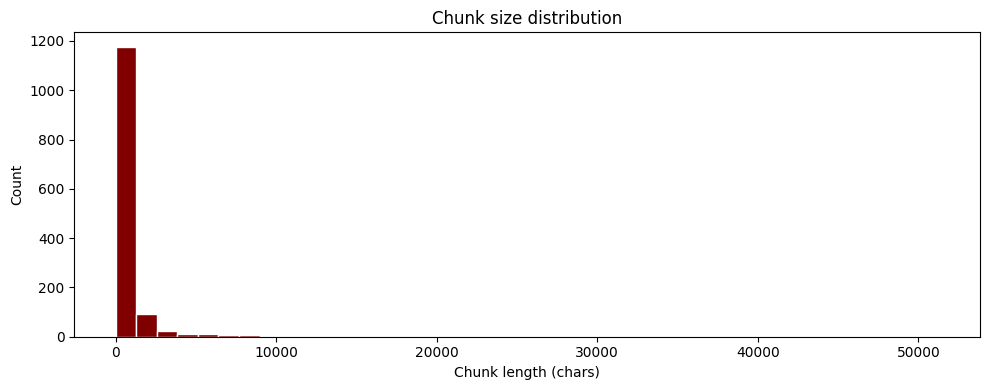

In [19]:
# [Optional-EDA] Chunk length distribution
lengths = [len(c["text"]) for c in chunk_records]

print(f"Total chunks: {len(lengths)}")
print(f"Min:    {min(lengths)}")
print(f"Max:    {max(lengths)}")
print(f"Mean:   {np.mean(lengths):.0f}")
print(f"Median: {np.median(lengths):.0f}")
print(f"P25/P75: {np.percentile(lengths,25):.0f} / {np.percentile(lengths,75):.0f}")

# Flag unusually small or large chunks
too_small = [c for c in chunk_records if len(c["text"]) < 100]
too_large = [c for c in chunk_records if len(c["text"]) > 1200]
print(f"\nChunks < 100 chars:  {len(too_small)}")
print(f"Chunks > 1200 chars: {len(too_large)}")

plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=40, color="#800000", edgecolor="white")
plt.xlabel("Chunk length (chars)")
plt.ylabel("Count")
plt.title("Chunk size distribution")
plt.tight_layout()
plt.show()


In [20]:
# [Optional-DEBUG] Inspect sample chunk structure
# Inspect a sample chunk structure
sample = next(c for c in chunk_records if c["metadata"].get("chunk_type") == "accordion")
pprint.pprint(sample)


{'chunk_id': 'chunk_25_Jobs_&_Opportunities_|_DSI',
 'metadata': {'chunk_type': 'accordion',
              'heading': 'Faculty',
              'labels': ['career'],
              'level': 'Specific',
              'page_title': 'Jobs & Opportunities | DSI',
              'source_url': 'https://datascience.uchicago.edu/about/jobs/',
              'sub_heading': None},
 'text': 'Faculty\n'
         'Associate Professor of Data Science\n'
         'The University of Chicago invites applications for tenured faculty '
         'positions at the rank of Associate Professor in the area of Data '
         'Science. Appointments may be made in either the Department of '
         'Computer Science or the Department of Statistics, jointly between '
         'Statistics and Computer Science, or jointly with another department '
         'in the University. Members of the faculty are expected to lead '
         'research programs that will produce significant contributions to a '
         'field, a

### 2.2 Embedding

Encode all chunks using `sentence-transformers/all-MiniLM-L6-v2` (384-dim).
Embeddings are L2-normalized and stored in a FAISS `IndexFlatIP` (inner product = cosine similarity).

In [21]:
model_name = 'sentence-transformers/all-MiniLM-L6-v2'
embedder = SentenceTransformer(model_name, device='mps')

texts = [chunk['text'] for chunk in chunk_records]
embeddings = embedder.encode(texts, batch_size=32, show_progress_bar=True)

print(f"Generated {len(embeddings)} embeddings.")

Batches:   0%|          | 0/42 [00:00<?, ?it/s]

Generated 1342 embeddings.


In [22]:
# BM25 index
tokenized = [c["text"].lower().split() for c in chunk_records]
bm25 = BM25Okapi(tokenized)

# Cross-encoder reranker
cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

print("BM25 and cross-encoder ready.")


BM25 and cross-encoder ready.


In [23]:
np.save("embeddings.npy", embeddings) 

In [24]:
metadata = [rec["metadata"] for rec in chunk_records]

# Normalize for cosine similarity (inner product on unit vectors = cosine)
dimension = embeddings.shape[1]
vecs = embeddings.astype("float32")
norms = np.linalg.norm(vecs, axis=1, keepdims=True)
norms[norms == 0] = 1
vecs /= norms

index = faiss.IndexFlatIP(dimension)
index.add(vecs)
print(f"FAISS IndexFlatIP built: {index.ntotal} vectors x {dimension} dims")

faiss.write_index(index, "uchicago_ads_faiss.index")
with open("uchicago_ads_faiss_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)
print("Saved uchicago_ads_faiss.index and uchicago_ads_faiss_metadata.json")


FAISS IndexFlatIP built: 1342 vectors x 384 dims
Saved uchicago_ads_faiss.index and uchicago_ads_faiss_metadata.json


In [25]:
# [Optional-UNUSED] Query label extraction (not called downstream)
def extract_query_labels(query, keyword_groups):
    query_norm = normalize(query)
    labels = []
    for group, syns in keyword_groups.items():
        if any(s.lower() in query_norm for s in syns):
            labels.append(group)
    return labels

"""
def classify_query_level(query, general_keywords, specific_keywords):
    q = query.lower()
    g_score = sum(kw in q for kw in general_keywords)
    s_score = sum(kw in q for kw in specific_keywords)
    if s_score > g_score:
        return "Specific"
    else:
        return "General"
"""

'\ndef classify_query_level(query, general_keywords, specific_keywords):\n    q = query.lower()\n    g_score = sum(kw in q for kw in general_keywords)\n    s_score = sum(kw in q for kw in specific_keywords)\n    if s_score > g_score:\n        return "Specific"\n    else:\n        return "General"\n'

In [26]:
query_text_list = [
    "What are the core courses in the MS in Applied Data Science program?",
    "What are the admission requirements for the program?",
    "Tell me about the capstone project.",
    "What is the tuition cost for the program?",
    "What scholarships are available for the program?",
    "What are the minimum scores for the TOEFL and IELTS English Language Requirement?",
    "Is there an application fee waiver?",
    "What are the deadlines for the in-person program?",
    "How long will it take for me to receive a decision on my application?",
    "Can I set up an advising appointment with the enrollment management team?",
    "Where can I mail my official transcripts?",
    "Does the Master’s in Applied Data Science Online program provide visa sponsorship?",
    "How do I apply to the MBA/MS program?",
    "Is the MS in Applied Data Science program STEM/OPT eligible?",
    "How many courses must you complete to earn UChicago’s Master’s in Applied Data Science?"]

### 2.3 Retrieval

Hybrid retrieval with three signals fused via Reciprocal Rank Fusion (RRF, k=60):
1. **BM25** — keyword matching with bidirectional synonym expansion
2. **Semantic** — FAISS cosine similarity
3. **Heading boost** — extra score for chunks whose heading overlaps with query keywords (2x multiplier for parent chunk types)

Post-fusion filtering: per-URL cap (3 for normal queries, 1 for list queries) and near-duplicate removal (Jaccard > 0.95).

Cross-encoder reranking (`ms-marco-MiniLM-L-6-v2`) re-scores the top candidates. Retrieval rank 1 is always preserved to prevent the cross-encoder from dropping important parent chunks (which it penalizes due to 512-token limit).

**Tried and removed:**
- **HyDE (Hypothetical Document Embedding)**: gemini-2.5-flash-lite hallucinated wrong course names (e.g., "Data Science I and II" instead of actual courses), poisoning semantic search. Embedding space mismatch between list-format HyDE output and prose-format chunks further degraded results.
- **Label-based filtering**: Attempted to filter chunks by topic labels at retrieval time, but labels were too coarse and caused relevant chunks to be excluded.

In [27]:
# ---------------------------------------------------------------------------
# List-query detection (mirrors main.py)
# ---------------------------------------------------------------------------
_LIST_RE = re.compile(
    r"\b(\d+)\s*(examples?|instances?|cases?|capstones?|projects?|topics?|courses?|ways?|tips?|ideas?)"
    r"|\b(list|give me|show me|what are|name)\b",
    re.IGNORECASE,
)

def _requested_count(query):
    m = re.search(r"\b(\d+)\s*(examples?|instances?|cases?|capstones?|projects?)", query, re.IGNORECASE)
    return int(m.group(1)) if m else 0

def is_list_query(query):
    return bool(_LIST_RE.search(query))

_SYNONYMS = {
    "tuition":              ["cost", "fee", "price", "expense", "how much"],
    "professor":            ["faculty", "instructor", "teacher"],
    "class":                ["course", "subject"],
    "job":                  ["career", "employment", "work", "hire", "company", "role"],
    "career outcomes":      ["hire", "company", "employer", "job placement", "work at"],
    "salary":               ["income", "pay", "compensation", "earning"],
    "apply":                ["application", "admission", "enroll"],
    "admission":            ["application", "how to apply", "eligibility", "requirement"],
    "scholarship":          ["financial aid", "funding", "grant", "award"],
    "online":               ["remote", "virtual", "distance"],
    "deadline":             ["due date", "cutoff"],
    "gpa":                  ["grade", "academic requirement"],
    "visa":                 ["immigration", "sponsorship", "opt", "stem"],
    "capstone":             ["project", "thesis", "final project"],
    "curriculum":           ["core courses", "required courses", "elective courses", "course list"],
    "alumni":               ["graduate", "graduate outcome", "placement"],
    "core courses":         ["required courses", "mandatory classes"],
    "foundational courses": ["before join","resources before joining", "preparation materials", "pre-course resources"],
}

# Build reverse index: synonym value → canonical key
_REVERSE_SYNONYMS = {}
for key, vals in _SYNONYMS.items():
    for v in vals:
        _REVERSE_SYNONYMS[v] = key

def _phrase_matches(phrase, q_lower):
    """All words in phrase must appear in query (order-independent).
    Handles inserted words like 'before students officially join'.
    """
    q_tokens = set(re.sub(r"[^a-z0-9\s]", " ", q_lower).split())
    words = phrase.split()
    if len(words) == 1:
        return words[0] in q_tokens
    return all(w in q_tokens for w in words)


def expand_query(query: str) -> str:
    """Bidirectional synonym expansion for BM25.
    - Forward:  "foundational courses" → adds values (preparation materials, ...)
    - Backward: "resources before joining" → adds canonical key (foundational courses)
    Uses bag-of-words matching so inserted words don't break multi-word phrases.
    """
    q_lower = query.lower()
    extra = []
    all_phrases = sorted(
        list(_SYNONYMS.keys()) + list(_REVERSE_SYNONYMS.keys()),
        key=len, reverse=True
    )
    for phrase in all_phrases:
        if _phrase_matches(phrase, q_lower):
            if phrase in _SYNONYMS:
                extra.extend(_SYNONYMS[phrase])
            else:
                extra.append(_REVERSE_SYNONYMS[phrase])
    return query + " " + " ".join(extra) if extra else query


def is_dup(a, b, thresh=0.95):
    sa, sb = set(a.split()), set(b.split())
    return len(sa & sb) / max(1, len(sa | sb)) > thresh


# ---------------------------------------------------------------------------
# Hybrid retrieval: BM25 + FAISS fused with RRF
# ---------------------------------------------------------------------------
def retrieve(query, top_k=10, dup_thresh=0.95):
    listing = is_list_query(query)
    url_cap = 1 if listing else 3

    all_idxs = list(range(len(chunk_records)))
    q_emb = embedder.encode([query], normalize_embeddings=True)[0].astype("float32")
    bm25_scores = bm25.get_scores(expand_query(query).lower().split())

    sub_vecs = np.stack([index.reconstruct(i) for i in all_idxs])
    sem_scores = sub_vecs @ q_emb

    k = 60
    sem_ranks  = np.argsort(-sem_scores)
    bm25_ranks = np.argsort(-bm25_scores)
    rrf = np.zeros(len(all_idxs))
    for rank, rel in enumerate(sem_ranks):
        rrf[rel] += 1.0 / (k + rank + 1)
    for rank, rel in enumerate(bm25_ranks):
        rrf[rel] += 1.0 / (k + rank + 1)

    # Heading boost: boost chunks whose heading overlaps with query keywords
    q_tokens = set(re.sub(r"[^a-z0-9\s]", " ", query.lower()).split())
    q_tokens.update(expand_query(query).lower().split())
    for idx in all_idxs:
        heading = (chunk_records[idx]["metadata"].get("heading") or "").lower()
        if not heading:
            continue
        h_tokens = set(heading.split())
        overlap = len(q_tokens & h_tokens) / max(1, len(h_tokens))
        if overlap >= 0.5:
            ctype = chunk_records[idx]["metadata"].get("chunk_type", "")
            multiplier = 2.0 if ctype in ("accordion", "page") else 1.0
            rrf[idx] += overlap * 0.02 * multiplier

    order = np.argsort(-rrf)
    hits, seen_texts, url_count = [], [], {}

    for rel in order:
        if len(hits) >= top_k:
            break
        text = chunk_records[rel]["text"]
        if any(is_dup(text, s, dup_thresh) for s in seen_texts):
            continue
        url = chunk_records[rel]["metadata"]["source_url"]
        url_count.setdefault(url, 0)
        if url_count[url] >= url_cap:
            continue
        url_count[url] += 1
        seen_texts.append(text)
        hits.append({
            "chunk_id": chunk_records[rel]["chunk_id"],
            "text":     text,
            "url":      url,
            "labels":   chunk_records[rel]["metadata"].get("labels", []),
            "score":    float(rrf[rel]),
        })
    return hits


# ---------------------------------------------------------------------------
# Cross-encoder reranking
# ---------------------------------------------------------------------------
def rerank(query, hits, top_k=5):
    n = max(top_k, _requested_count(query))
    pairs  = [(query, h["text"]) for h in hits]
    scores = cross_encoder.predict(pairs)
    ranked = sorted(zip(scores, hits), key=lambda x: -x[0])
    result = [h for _, h in ranked[:n]]
    # Preserve retrieval rank 1 (highest RRF) even if cross-encoder drops it
    if hits and hits[0] not in result:
        result.insert(0, hits[0])
    return result


print("retrieve() and rerank() ready.")


retrieve() and rerank() ready.


In [28]:
# [Optional-DEBUG] Test single retrieval query
hits = retrieve("Tell me about the capstone project.")
for h in hits:
    print(h)


{'chunk_id': 'chunk_1082_Online_Program_|_DSI', 'text': 'Core Courses — Data Science Capstone Project\nThe required Capstone Project is completed over two quarters and covers research design, implementation, and writing.\nFull-time students start their capstone project in their third quarter. Part-time students generally begin the capstone project in their fifth quarter.', 'url': 'https://datascience.uchicago.edu/education/masters-programs/ms-in-applied-data-science/online-program/', 'labels': ['other'], 'score': 0.029211087420042643}
{'chunk_id': 'chunk_777_Online_Program_|_DSI', 'text': 'Capstone (2)\nThe required\nCapstone Project\nis completed over 2 quarters and covers research design, implementation, and writing. Full-time students start their\nCapstone Project\nin their third quarter. Part-time students generally begin the\nCapstone Project\ntwo quarters before their projected\ngraduation\nquarter. Students choose among industry- and research-focused projects.\nAdditional Resour

In [29]:
# [Optional-DEBUG] Test batch retrieval on all queries
query_text_list = [
    "What are the core courses in the MS in Applied Data Science program?",
    "What are the admission requirements for the program?",
    "Tell me about the capstone project.",
    "What is the tuition cost for the program?",
    "What scholarships are available for the program?",
    "What are the minimum scores for the TOEFL and IELTS English Language Requirement?",
    "Is there an application fee waiver?",
    "What are the deadlines for the in-person program?",
    "How long will it take for me to receive a decision on my application?",
    "Can I set up an advising appointment with the enrollment management team?",
    "Where can I mail my official transcripts?",
    "Does the Master's in Applied Data Science Online program provide visa sponsorship?",
    "How do I apply to the MBA/MS program?",
    "Is the MS in Applied Data Science program STEM/OPT eligible?",
    "How many courses must you complete to earn UChicago's Master's in Applied Data Science?"]

for query in query_text_list:
    results = retrieve(query)

    print(query)
    for i, res in enumerate(results, 1):
        print(f"Top {i}: (Score: {res["score"]:.3f})")
        print(f"URL: {res["url"]}")
        print(f"Labels: {res["labels"]}")
        print(f"Content: {res["text"][:300]} ...")


What are the core courses in the MS in Applied Data Science program?
Top 1: (Score: 0.048)
URL: https://datascience.uchicago.edu/education/masters-programs/ms-in-applied-data-science/online-program/%20
Labels: ['other']
Content: Core Courses
Time Series Analysis and Forecasting
Time Series Analysis is a science as well as the art of making rational predictions based on previous records. It is widely used in various fields in today’s business settings.
Statistical Models for Data Science
In a traditional linear model, the ob ...
Top 2: (Score: 0.039)
URL: https://datascience.uchicago.edu/education/masters-programs/in-person-program/
Labels: ['other']
Content: Core Courses — Data Science Capstone Project
The required Capstone Project is completed over two quarters and covers research design, implementation, and writing.
Full-time students start their capstone project in their third quarter. Part-time students generally begin the capstone project in their  ...
Top 3: (Score: 0.038)
URL: h

## 3. LLM Integration

Generate answers using `gemini-2.5-flash-lite` with retrieved context.

Prompt design:
- Explicit instruction to NOT start with disclaimers
- Terminology bridging (e.g., "how to apply" content answers "admission requirements" questions)
- Markdown output format for frontend rendering
- List detection adjusts instruction and retrieval depth

In [30]:
load_dotenv()

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash-lite",
    temperature=0.0,
    max_output_tokens=512,
    google_api_key=os.getenv("GOOGLE_API_KEY"),
)


In [31]:
def rag_generate_with_LLM(query, top_k=5):
    listing = is_list_query(query)
    retrieve_k = 20 if listing else 10
    rerank_k = max(top_k, _requested_count(query)) if listing else top_k
    candidates = retrieve(query, top_k=retrieve_k)
    hits = rerank(query, candidates, top_k=rerank_k)

    if not hits:
        return "I'm sorry, I don't have enough information to answer that question."

    listing = is_list_query(query)
    instruction = "List each item clearly and separately." if listing else "Answer concisely and directly."

    context = "\n\n".join(f"[Doc] {h['text']}" for h in hits)
    prompt = (
        "You are a helpful assistant for University of Chicago's MS in Applied Data Science program.\n"
        "Use the provided context below to answer the user question. "
        f"{instruction} "
        "IMPORTANT: Do NOT start with disclaimers or statements about what the context lacks. "
        "If the context contains relevant information -- even under different terminology -- "
        "treat it as a direct answer and synthesize ALL relevant details. "
        "Only say you don't know if the context is completely unrelated. "
        "Format your answer in Markdown.\n\n"
        f"[CONTEXT]\n{context}\n\n"
        f"[QUESTION]\n{query}\n\n"
        "Answer:"
    )
    return llm.invoke(prompt).content.strip()


### 3.1 Test — Sample Query

In [32]:
# [Optional-DEBUG] Test single LLM generation
query = "What resources does the program offer before students officially join?"
answer = rag_generate_with_LLM(query)

print("=== Answer ===")
print(answer)


=== Answer ===
Before officially joining the program, students can opt to take four noncredit Foundational courses: Introduction to Statistical Concepts, R for Data Science, Python for Data Science, and Advanced Linear Algebra for Machine Learning. The first two are pre-quarter courses held in the five weeks leading up to the first quarter, while Python for Data Science is held concurrently with the first five weeks of the first quarter, and Advanced Linear Algebra for Machine Learning is held concurrently with the second five weeks of the first quarter. All Foundational courses are completed virtually. Alternatively, students can complete a required online Foundational Skills Assessment.


In [33]:
# [Optional-DEBUG] Filter RAGAS results for specific queries
answer_list = {}
for query in query_text_list:
    answer = rag_generate_with_LLM(query)
    print("\n" + "-" * 60)
    print(query)
    print("=== Answer ===")
    print(answer)
    answer_list[query] = answer



------------------------------------------------------------
What are the core courses in the MS in Applied Data Science program?
=== Answer ===
*   Time Series Analysis and Forecasting
*   Statistical Models for Data Science
*   Machine Learning I
*   Machine Learning II
*   Data Engineering Platforms for Analytics or Big Data and Cloud Computing
*   Leadership and Consulting for Data Science
*   Data Science Capstone Project

------------------------------------------------------------
What are the admission requirements for the program?
=== Answer ===
*   **Application Portal:** The application portal for 2026 entrance is open. It may close early if the cohort is filled.
*   **Program Formats:** The program admits full- and part-time students for entrance in the autumn quarter annually, in both in-person and online formats.
*   **Application Deadlines (Autumn 2026):**
    *   **In-Person:**
        *   May 6, 2026 – Third Priority Application Deadline
        *   June 23, 2026 – Fi

### 3.2 Test — Additional Queries

In [34]:
query_text_test = [
    "What kind of careers can the student have after graduate from this program?",
    "How can I apply to the NorthWestern University machine learning and data science program",
    "How many students are there in the in-person program?",
    "Can you give me some examples of the capstone projects?",
    "Can you give me some professor names and their introduction related to generative AI?",
    "Does this program cares about DEI?",
    "What kind of scholarships does this program provide?",
    "What companies can students join after graduation? Give me some examples",
    "How many courses do the students take each quarter?",
    "How many courses the students should take to meet the graduation requirements?",
    "What resources does the program offer before students officially join?"
]

for query in query_text_test:
    answer = rag_generate_with_LLM(query)
    print("" + "-" * 60)
    print(query)
    print("=== Answer ===")
    print(answer)


------------------------------------------------------------
What kind of careers can the student have after graduate from this program?
=== Answer ===
Graduates of the MS in Applied Data Science program can pursue diverse career paths in leading industries and at top employers such as JPMorganChase, Google, and Amazon. The median post-graduation salary is $130,000.
------------------------------------------------------------
How can I apply to the NorthWestern University machine learning and data science program
=== Answer ===
I cannot answer your question as the provided context is about the University of Chicago's MS in Applied Data Science program and does not contain information about Northwestern University's machine learning and data science program.
------------------------------------------------------------
How many students are there in the in-person program?
=== Answer ===
I cannot provide the exact number of students in the in-person program. The provided context describes

## 4. Evaluation

Three evaluation approaches to measure retrieval and generation quality.

### 4.1 Pseudo-Query Recall

Generate synthetic queries from chunk text using LLM, then check if the source chunk
is retrieved in the top-k results. Measures retrieval coverage without human-labeled queries.

In [35]:
def evaluate_recall_with_retriever(n_samples=100, k=5):
    pseudo = []
    for rec in random.sample(chunk_records, min(n_samples, len(chunk_records))):
        sent = rec["text"].split(".")[0].strip()
        pseudo.append((sent, rec["chunk_id"]))

    r1 = 0
    rK = 0
    for query, true_id in pseudo:
        hits = retrieve(query, top_k=k)
        retrieved_ids = [h["chunk_id"] for h in hits]
        if not retrieved_ids:
            continue
        if retrieved_ids[0] == true_id:
            r1 += 1
        if true_id in retrieved_ids:
            rK += 1

    total = len(pseudo)
    print(f"Recall@1: {r1/total:.3f} ({r1}/{total})")
    print(f"Recall@{k}: {rK/total:.3f} ({rK}/{total})")


In [36]:
evaluate_recall_with_retriever(n_samples=100, k=5)


Recall@1: 0.270 (27/100)
Recall@5: 0.600 (60/100)


### 4.2 Retriever Distribution

Analyze the embedding space distribution of retrieved chunks vs. the full corpus
to check for retrieval bias or dead zones.

In [37]:
def eval_retrieved_embed_distribution(queries, k=5):
    top1_scores = []
    topk_scores = []

    for q in queries:
        hits = retrieve(q, top_k=k)
        if not hits:
            continue
        scores = [h["score"] for h in hits]
        top1_scores.append(scores[0])
        topk_scores.append(np.mean(scores))

    if top1_scores:
        print(f"Top-1 score  avg: {np.mean(top1_scores):.4f}  std: {np.std(top1_scores):.4f}")
    else:
        print("No Top-1 results.")
    if topk_scores:
        print(f"Top-{k} score avg: {np.mean(topk_scores):.4f}  std: {np.std(topk_scores):.4f}")
    else:
        print(f"No Top-{k} results.")


In [38]:
eval_retrieved_embed_distribution(
    queries=query_text_list + query_text_test,
    k=5,
)


Top-1 score  avg: 0.0414  std: 0.0114
Top-5 score avg: 0.0326  std: 0.0056


### RAGAS Evaluation

Measures answer quality (no ground truth required):
- **Faithfulness**: are claims in the answer supported by retrieved context?
- **Answer Relevancy**: is the answer relevant to the question, without unnecessary info?


In [39]:
OUT_OF_DOMAIN_INDICES = {16}  # Northwestern question — not about UChicago ADS
all_queries = query_text_list + query_text_test
eval_queries = [q for i, q in enumerate(all_queries) if i not in OUT_OF_DOMAIN_INDICES]

questions = []
answers = []
contexts = []

print(f"Collecting RAG outputs for {len(eval_queries)} queries...")
for i, query in enumerate(eval_queries):
    hits = retrieve(query, top_k=5)
    answer = rag_generate_with_LLM(query, top_k=5)
    questions.append(query)
    answers.append(answer)
    contexts.append([h["text"] for h in hits])
    print(f"  [{i+1}/{len(eval_queries)}] done")

ragas_dataset = Dataset.from_dict({
    "question": questions,
    "answer": answers,
    "contexts": contexts,
})
print("Dataset ready.")


  [1/25] done
  [2/25] done
  [3/25] done
  [4/25] done
  [5/25] done
  [6/25] done
  [7/25] done
  [8/25] done
  [9/25] done
  [10/25] done
  [11/25] done
  [12/25] done
  [13/25] done
  [14/25] done
  [15/25] done
  [16/25] done
  [17/25] done
  [18/25] done
  [19/25] done
  [20/25] done
  [21/25] done
  [22/25] done
  [23/25] done
  [24/25] done
  [25/25] done
Dataset ready.


In [40]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", DeprecationWarning)
    ragas_llm = LangchainLLMWrapper(ChatGoogleGenerativeAI(
        model="gemini-2.5-flash", temperature=0
    ))
    ragas_embeddings = LangchainEmbeddingsWrapper(
        HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
    )

result = evaluate(
    ragas_dataset,
    metrics=[faithfulness, answer_relevancy],
    llm=ragas_llm,
    embeddings=ragas_embeddings,
)

df = result.to_pandas()

print("=== RAGAS Evaluation Results ===")
print(f"Faithfulness:     {df['faithfulness'].mean():.4f}")
print(f"Answer Relevancy: {df['answer_relevancy'].mean():.4f}")
print("Per-question breakdown:")
print(df[["user_input", "faithfulness", "answer_relevancy"]].to_string(index=False))


Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


=== RAGAS Evaluation Results ===
Faithfulness:     0.8600
Answer Relevancy: 0.7066
Per-question breakdown:
                                                                             user_input  faithfulness  answer_relevancy
                   What are the core courses in the MS in Applied Data Science program?      1.000000          0.823408
                                   What are the admission requirements for the program?      1.000000          0.630850
                                                    Tell me about the capstone project.      0.555556          0.949975
                                              What is the tuition cost for the program?      1.000000          0.743608
                                       What scholarships are available for the program?      1.000000          0.772775
      What are the minimum scores for the TOEFL and IELTS English Language Requirement?      1.000000          0.918003
                                                    I

In [41]:
# [Optional-DEBUG] Filter RAGAS results for specific queries
df[df["user_input"].str.contains("capstone")][["user_input", "response", "faithfulness", "answer_relevancy"]]

,user_input,response,faithfulness,answer_relevancy
2,Tell me about the capstone project.,"The Capstone Project is a required, two-quarte...",0.555556,0.949975
17,Can you give me some examples of the capstone ...,Here are some examples of Capstone Projects fr...,0.900000,0.753605


In [44]:
# [Optional-DEBUG] Debug utility — trace full query pipeline
def debug_query(query: str):
    print(f"{'='*60}")
    print(f"Query: {query}")
    
    # 1. Synonym expansion
    expanded = expand_query(query)
    if expanded != query:
        print(f"\n[Synonym expansion] {expanded[len(query):]}")
    else:
        print("\n[Synonym expansion] none triggered")

    # 2. Retrieval candidates
    candidates = retrieve(query, top_k=10)
    print(f"\n[Retrieval candidates top-10]")
    for i, h in enumerate(candidates):
        print(f"  {i+1}. [RRF={h['score']:.4f}] {h['url'].split('/')[-2]}")
        print(f"     {h['text'][:800].strip()}")

    # 4. After reranking
    hits = rerank(query, candidates, top_k=5)
    print(f"\n[After reranking top-5]")
    for i, h in enumerate(hits):
        print(f"  {i+1}. {h['url'].split('/')[-2]}")
        print(f"     {h['text'][:800].strip()}")

    # 5. Final answer
    answer = rag_generate_with_LLM(query)
    print(f"\n[Final answer]\n{answer}")
    print('='*60)

# Usage
debug_query("How many courses must you complete to earn UChicago's Master's in Applied Data Science?")

Query: How many courses must you complete to earn UChicago's Master's in Applied Data Science?

[Synonym expansion] none triggered

[Retrieval candidates top-10]
  1. [RRF=0.0323] in-person-program
     Noncredit Courses
Career Seminar (Seminar, required)
The Pass/Fail Career Seminar supports the development of industry professional skills, job and/or internship searches, and other in-demand areas of competency among today’s employers. Students enroll in the Career Seminar each quarter in order to engage in unique content throughout their degree program. Students with significant full-time work experience may be eligible to waive this course. 0 units, no cost.
Introduction to Statistical Concepts (Foundational, optional)
This course is held in the five weeks leading up to the start of your first quarter and provides general exposure to basic statistical concepts necessary for success in advanced courses in the program. 0 units, no cost.
R for Data Science (Foundational, optional)
This 